# Morphing study (Simple HEP toy)

This notebook examines the following:
$$
u(x\mid \theta)\equiv \nu(\theta)\,p(x\mid\theta)=\sum_{i=1}^{N_{\rm basis}} w_i(\theta)\,u_i(x),\qquad
u_i(x)\equiv \nu(\theta_i)\,p(x\mid\theta_i),
$$
into a **CFM/CNF** workflow where each $u_i(x)$ is learned by a flow (trained with flow matching), and the **analytic morphing weights** $w_i(\theta)$ are used at inference time.

$w_i(\theta)$ can be **negative** (Lagrange-style morphing). That means $u(x\mid\theta)$ is a **signed linear combination** of *positive* densities $u_i(x)$, but physics guarantees $u(x\mid\theta)\ge 0$ in the valid region. Numerically, must evaluate the signed sum stably.


In [1]:
import numpy as np
import torch

torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


## Morphing weights

We use the monomial basis
$$
b(\theta)=\big[\kappa'^2\cos^2\alpha,\;\kappa'\cos\alpha,\;\kappa'^2\sin^2\alpha,\;\kappa'\sin\alpha,\;\kappa'^2\cos\alpha\sin\alpha,\;1\big],
$$
and the fixed inverse morphing matrix $G^{-1}$ to obtain
$$
w(\theta)=b(\theta)^\top G^{-1}.
$$


In [2]:
class MorphingWeights(torch.nn.Module):
    def __init__(self, basis_points):
        super().__init__()
        basis_points = np.asarray(basis_points, dtype=float)
        G = np.array([
            [k**2*np.cos(a)**2, k*np.cos(a), k**2*np.sin(a)**2, k*np.sin(a), k**2*np.cos(a)*np.sin(a), 1.0]
            for k,a in basis_points
        ], dtype=float)
        G_inv = np.linalg.inv(G) if G.shape[0]==G.shape[1] else np.linalg.pinv(G)
        self.register_buffer("G_inv", torch.tensor(G_inv, dtype=torch.float32))  # [6,6]

    @staticmethod
    def monomials(kappa, alpha):
        kappa = torch.as_tensor(kappa)
        alpha = torch.as_tensor(alpha)
        c, s = torch.cos(alpha), torch.sin(alpha)
        return torch.stack([kappa**2*c**2, kappa*c, kappa**2*s**2, kappa*s, kappa**2*c*s, torch.ones_like(kappa)], dim=-1)

    def forward(self, kappa, alpha):
        b = self.monomials(kappa, alpha)                # [...,6]
        w = b @ self.G_inv                              # [...,6]  (N_basis==6 here)
        return w

basis_points = [
    (1.0, 0.0),
    (1.0, np.pi/2),
    (1.0, np.pi/4),
    (1.5, np.pi/6),
    (0.5, np.pi/3),
    (1.0, np.pi/8),
]
W = MorphingWeights(basis_points).to(device)

# quick sanity check (weights can be negative)
kappa = torch.tensor([1.0], dtype=torch.float32, device=device)
alpha = torch.tensor([np.radians(10.0)], dtype=torch.float32, device=device)
print("w(theta):", W(kappa, alpha))


w(theta): tensor([[ 0.3939,  0.0267, -0.2128, -0.0126, -0.0210,  0.8258]])


## 2) Stable signed log-sum-exp

Given per-basis log-unnormalised densities $\log u_i(x)$ and weights $w_i(\theta)$, we need
$$
u(x\mid\theta)=\sum_i w_i(\theta)\,\exp(\log u_i(x)).
$$
We compute positive and negative parts:
$$
u = u_+ - u_-,\qquad
u_+ = \sum_{i:w_i>0} w_i e^{\log u_i},\quad
u_- = \sum_{i:w_i<0} |w_i| e^{\log u_i}.
$$
Then $\log u = \log(u_+ - u_-)$ requires $u_+>u_-$.


In [3]:
def _logsumexp_weighted(log_u, w, eps=1e-30):
    """
    log_u: [B, K] log u_i(x)
    w:     [B, K] nonnegative weights
    returns: [B] log sum_i w_i * exp(log_u_i)
    """
    w = torch.clamp(w, min=0.0)
    log_w = torch.log(w + eps)
    return torch.logsumexp(log_u + log_w, dim=-1)

def signed_logsumexp(log_u, w, eps=1e-30):
    """
    Computes log( sum_i w_i * exp(log_u_i) ) with signed w_i.
    Returns:
      log_abs: [B] log |sum|
      sign:    [B] in {-1,+1}
      valid:   [B] True if result is strictly positive (sign=+1)
    """
    w_pos = torch.clamp(w, min=0.0)
    w_neg = torch.clamp(-w, min=0.0)

    log_pos = _logsumexp_weighted(log_u, w_pos, eps=eps)  # log u_+
    log_neg = _logsumexp_weighted(log_u, w_neg, eps=eps)  # log u_-

    diff = log_neg - log_pos
    valid = diff < 0

    log_abs = torch.empty_like(log_pos)
    log_abs[valid] = log_pos[valid] + torch.log1p(-torch.exp(diff[valid]))
    log_abs[~valid] = log_pos[~valid]  # placeholder, caller should mask

    sign = torch.ones_like(log_pos)
    sign[~valid] = -1.0
    return log_abs, sign, valid


## Flow matching model interface

For each basis point $i$, train a **continuous normalising flow (CNF)** using a flow-matching objective (rectified flow / conditional flow matching).

- sampling: $z\sim\mathcal N(0,I)\mapsto x$ (forward ODE),
- density evaluation: $\log p_i(x)$ (backward ODE + divergence integral).


In [4]:
class VectorField(torch.nn.Module):
    def __init__(self, x_dim, n_basis, emb_dim=32, hidden=256):
        super().__init__()
        self.emb = torch.nn.Embedding(n_basis, emb_dim)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(x_dim + 1 + emb_dim, hidden),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden, x_dim),
        )

    def forward(self, x, t, k):
        # x: [B,D], t: [B,1], k: [B] int64
        e = self.emb(k)                          # [B,emb_dim]
        inp = torch.cat([x, t, e], dim=-1)
        return self.net(inp)                     # [B,D]

def rectified_flow_fm_loss(vf, x_data, k, sigma=0.0):
    """
    Standard rectified-flow style FM loss for each component k.
    x_data: [B,D] samples from p_k(x)
    k:      [B]   component labels
    """
    B, _ = x_data.shape
    z = torch.randn_like(x_data)
    t = torch.rand(B, 1, device=x_data.device)

    x_t = (1 - t) * z + t * x_data
    if sigma > 0:
        x_t = x_t + sigma * torch.randn_like(x_t)

    v_star = x_data - z
    v_hat  = vf(x_t, t, k)
    return torch.mean((v_hat - v_star)**2)


## Combine learned basis densities with morphing weights

Assume you can evaluate $\log p_i(x)$ for each basis flow and you know $\log \nu_i$ (expected yield at basis point). Define
$$
\log u_i(x)=\log\nu_i+\log p_i(x).
$$
Then the morphing unnormalized density is
$$
u(x\mid\theta)=\sum_i w_i(\theta)\,u_i(x).
$$

A convenient normalization in the same morphing approximation is
$$
\nu(\theta)\approx \sum_i w_i(\theta)\,\nu_i,
$$
so that
$$
\log p(x\mid\theta)=\log u(x\mid\theta)-\log \nu(\theta).
$$


In [5]:
def log_p_theta_from_basis(log_p_basis, log_nu_basis, w_theta, eps=1e-30):
    """
    log_p_basis:  [B,K]  log p_i(x) from learned flows
    log_nu_basis: [K]    log nu_i
    w_theta:      [B,K]  morphing weights at theta (signed)
    returns:
      log_p_theta: [B] log p(x|theta) (=-inf where invalid)
      valid:       [B] mask of valid events (positive combination)
    """
    log_u = log_p_basis + log_nu_basis[None, :]          # [B,K]
    log_u_theta, sign_u, valid_u = signed_logsumexp(log_u, w_theta, eps=eps)

    log_nu_theta, sign_nu, valid_nu = signed_logsumexp(
        log_nu_basis[None, :].expand_as(log_p_basis),
        w_theta,
        eps=eps,
    )

    valid = valid_u & valid_nu & (sign_u > 0) & (sign_nu > 0)

    log_p = torch.full_like(log_u_theta, -torch.inf)
    log_p[valid] = log_u_theta[valid] - log_nu_theta[valid]
    return log_p, valid


## Score w.r.t. $(\kappa',\alpha)$ from analytic weights

Because $u_i(x)$ do not depend on $\theta$, all $\theta$-dependence is in $w_i(\theta)$ (and $\nu(\theta)$). You get scores by differentiating through the weights:
$$
\nabla_\theta \log p(x\mid\theta)=
\frac{\sum_i (\nabla_\theta w_i(\theta))\,u_i(x)}{\sum_i w_i(\theta)\,u_i(x)}
-\nabla_\theta\log \nu(\theta).
$$


In [6]:
def score_theta_from_basis(u_basis, w_theta, dw_dtheta, nu_theta, dnu_dtheta):
    """
    u_basis:   [B,K]    u_i(x)=nu_i * p_i(x)  (linear space)
    w_theta:   [B,K]
    dw_dtheta: [B,K,2]  derivatives wrt (kappa, alpha)
    nu_theta:  [B]
    dnu_dtheta:[B,2]
    returns:
      score: [B,2]  grad_theta log p(x|theta)
    """
    num = torch.einsum("bk,bkq->bq", u_basis, dw_dtheta)      # [B,2]
    den = torch.einsum("bk,bk->b",  u_basis, w_theta)         # [B]
    term1 = num / den[:, None]
    term2 = dnu_dtheta / nu_theta[:, None]
    return term1 - term2


## Train basis models with FM and bridge matching (toy demo)

This section shows an end-to-end application of your morphing setup with both:

- **FM** (single velocity network), and
- **Bridge matching** (velocity + score networks).

We use a small synthetic 2D basis dataset for a runnable example. Replace `make_basis_dist` and dataset construction with your pheno simulator while keeping the same training/inference pattern.

x_train: (4800, 2) k_train: (4800,) K: 6


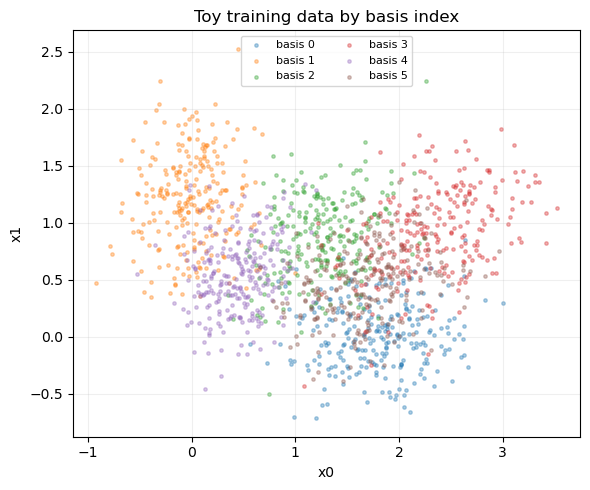

In [7]:
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal

import nami

K = len(basis_points)
x_dim = 2

CFG = {
    "n_train_per_basis": 800,
    "batch_size": 256,
    "fm_steps": 300,
    "bridge_steps": 300,
    "solver_steps": 32,
    "eval_samples": 1024,
    "mc_repeats": 1,
}


def make_basis_dist(kappa, alpha, *, device=device):
    """Toy basis distribution used only for this notebook demo."""
    kappa_t = torch.tensor(float(kappa), device=device)
    alpha_t = torch.tensor(float(alpha), device=device)
    c, s = torch.cos(alpha_t), torch.sin(alpha_t)

    mean = torch.stack([1.8 * kappa_t * c, 1.2 * kappa_t * s])
    rot = torch.stack([
        torch.stack([c, -s]),
        torch.stack([s, c]),
    ])

    scale_1 = 0.25 + 0.15 * kappa_t
    scale_2 = 0.15 + 0.10 * kappa_t
    cov_local = torch.diag(torch.stack([scale_1**2, scale_2**2]))
    cov = rot @ cov_local @ rot.T + 0.03 * torch.eye(x_dim, device=device)
    return MultivariateNormal(mean, cov)


basis_dists = [make_basis_dist(kappa, alpha) for (kappa, alpha) in basis_points]
log_nu_basis = torch.zeros(K, device=device)  # demo choice: nu_i = 1 for all basis points

x_chunks = []
k_chunks = []
for i, dist in enumerate(basis_dists):
    xi = dist.sample((CFG["n_train_per_basis"],))
    ki = torch.full((CFG["n_train_per_basis"],), i, dtype=torch.long, device=device)
    x_chunks.append(xi)
    k_chunks.append(ki)

x_train = torch.cat(x_chunks, dim=0)
k_train = torch.cat(k_chunks, dim=0)

print("x_train:", tuple(x_train.shape), "k_train:", tuple(k_train.shape), "K:", K)

fig, ax = plt.subplots(figsize=(6, 5))
for i in range(K):
    mask = k_train == i
    pts = x_train[mask][:250].detach().cpu()
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label=f"basis {i}")
ax.set_title("Toy training data by basis index")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.grid(alpha=0.2)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [8]:
class BasisIndexedField(torch.nn.Module):
    """Velocity/score field conditioned on discrete basis index k."""

    def __init__(self, x_dim, n_basis, emb_dim=32, hidden=192):
        super().__init__()
        self.emb = torch.nn.Embedding(n_basis, emb_dim)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(x_dim + 1 + emb_dim, hidden),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden, x_dim),
        )

    @property
    def event_ndim(self) -> int:
        return 1

    def forward(self, x, t, k=None):
        if k is None:
            raise ValueError("basis index k is required")

        lead = x.shape[:-1]

        # Accept scalar t, [*lead], or [*lead, 1].
        if t.ndim == len(lead) + 1 and t.shape[-1] == 1:
            t = t.squeeze(-1)
        if t.ndim == 0:
            t = t.expand(lead)
        elif tuple(t.shape) != tuple(lead):
            t = t.expand(lead)
        t = t.unsqueeze(-1)

        # Accept scalar k, [*lead], or [*lead, 1].
        if k.ndim == len(lead) + 1 and k.shape[-1] == 1:
            k = k.squeeze(-1)
        if k.ndim == 0:
            k = k.expand(lead)
        elif tuple(k.shape) != tuple(lead):
            k = k.expand(lead)
        k = k.long()

        e = self.emb(k)
        return self.net(torch.cat([x, t, e], dim=-1))


fm_field = BasisIndexedField(x_dim=x_dim, n_basis=K).to(device)
fm_opt = torch.optim.Adam(fm_field.parameters(), lr=1e-3)
fm_losses = []

for step in range(1, CFG["fm_steps"] + 1):
    idx = torch.randint(0, x_train.shape[0], (CFG["batch_size"],), device=device)
    xb = x_train[idx]
    kb = k_train[idx]

    loss = rectified_flow_fm_loss(fm_field, xb, kb)

    fm_opt.zero_grad()
    loss.backward()
    fm_opt.step()

    fm_losses.append(loss.item())
    if step % 100 == 0 or step == 1:
        print(f"FM step {step:4d} | loss {loss.item():.4f}")


FM step    1 | loss 2.6406
FM step  100 | loss 0.7556
FM step  200 | loss 0.6665
FM step  300 | loss 0.6845


Bridge step    1 | loss 18.2094
Bridge step  100 | loss 13.9641
Bridge step  200 | loss 14.1191
Bridge step  300 | loss 63.0141


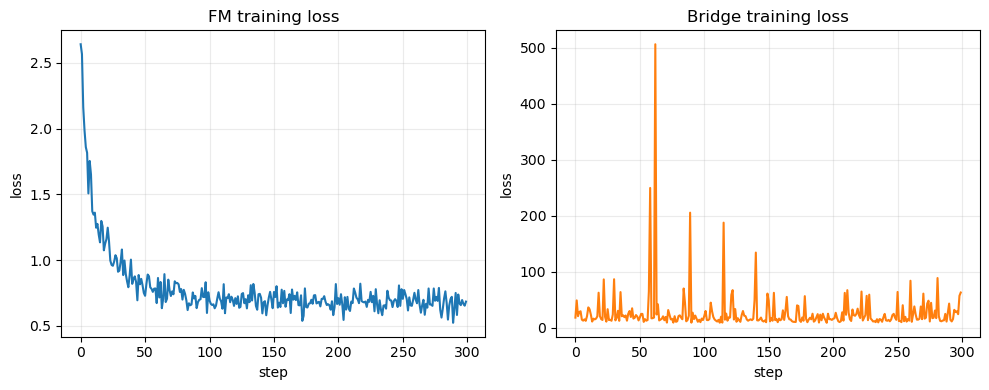

In [9]:
bridge_flow = BasisIndexedField(x_dim=x_dim, n_basis=K).to(device)
bridge_score = BasisIndexedField(x_dim=x_dim, n_basis=K).to(device)
bridge_opt = torch.optim.Adam(
    list(bridge_flow.parameters()) + list(bridge_score.parameters()),
    lr=1e-3,
)

bridge_path = nami.BrownianBridgePath(sigma=1.0)
bridge_losses = []

for step in range(1, CFG["bridge_steps"] + 1):
    idx = torch.randint(0, x_train.shape[0], (CFG["batch_size"],), device=device)
    x_target = x_train[idx]
    k_batch = k_train[idx]

    x_source = torch.randn_like(x_target)

    loss = nami.bridge_matching_loss(
        flow_field=bridge_flow,
        score_field=bridge_score,
        x_target=x_target,
        x_source=x_source,
        c=k_batch,
        path=bridge_path,
    )

    bridge_opt.zero_grad()
    loss.backward()
    bridge_opt.step()

    bridge_losses.append(loss.item())
    if step % 100 == 0 or step == 1:
        print(f"Bridge step {step:4d} | loss {loss.item():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fm_losses)
axes[0].set_title("FM training loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.25)

axes[1].plot(bridge_losses, color="tab:orange")
axes[1].set_title("Bridge training loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("loss")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [10]:
class FixedBasisField(torch.nn.Module):
    """Wrap a basis-indexed field into a standard field for one fixed basis i."""

    def __init__(self, indexed_field, basis_idx: int):
        super().__init__()
        self.indexed_field = indexed_field
        self.basis_idx = int(basis_idx)

    @property
    def event_ndim(self) -> int:
        return 1

    def forward(self, x, t, c=None):
        _ = c
        lead = x.shape[:-1]
        k = torch.full(lead, self.basis_idx, dtype=torch.long, device=x.device)
        return self.indexed_field(x, t, k)


def make_fm_processes(v_field, n_basis, *, solver_steps=32):
    base = nami.StandardNormal(event_shape=(x_dim,), device=device)
    processes = []
    for i in range(n_basis):
        field_i = FixedBasisField(v_field, i)
        fm = nami.FlowMatching(
            field=field_i,
            base=base,
            solver=nami.RK4(steps=solver_steps),
            t0=1.0,
            t1=0.0,
        )
        processes.append(fm(None))
    return processes


def make_bridge_processes(flow_field, score_field, n_basis, *, solver_steps=32):
    base = nami.StandardNormal(event_shape=(x_dim,), device=device)
    gamma = nami.BrownianGamma()
    processes = []
    for i in range(n_basis):
        flow_i = FixedBasisField(flow_field, i)
        score_i = FixedBasisField(score_field, i)
        drift_i = nami.DriftFromVelocityScore(flow_i, score_i, gamma)
        fm = nami.FlowMatching(
            field=drift_i,
            base=base,
            solver=nami.RK4(steps=solver_steps),
            t0=1.0,
            t1=0.0,
        )
        processes.append(fm(None))
    return processes


def log_p_basis_from_processes(
    processes,
    x,
    *,
    estimator,
    batch_size=128,
    mc_repeats=1,
):
    """Return [B,K] matrix of per-basis log p_i(x)."""
    all_basis = []
    for process in processes:
        mc_vals = []
        for _ in range(mc_repeats):
            vals = []
            for start in range(0, x.shape[0], batch_size):
                xb = x[start : start + batch_size]
                vals.append(process.log_prob(xb, estimator=estimator))
            mc_vals.append(torch.cat(vals, dim=0))
        all_basis.append(torch.stack(mc_vals, dim=0).mean(dim=0))
    return torch.stack(all_basis, dim=-1)


fm_processes = make_fm_processes(fm_field, K, solver_steps=CFG["solver_steps"])
bridge_processes = make_bridge_processes(
    bridge_flow,
    bridge_score,
    K,
    solver_steps=CFG["solver_steps"],
)

div_estimator = nami.HutchinsonDivergence(probe="rademacher")


     FM | valid_frac=0.739 | NLL(model)=4.202 | NLL(true)=0.789 | mean(logp_model-logp_true)=-3.413
 Bridge | valid_frac=1.000 | NLL(model)=4.332 | NLL(true)=0.959 | mean(logp_model-logp_true)=-3.373


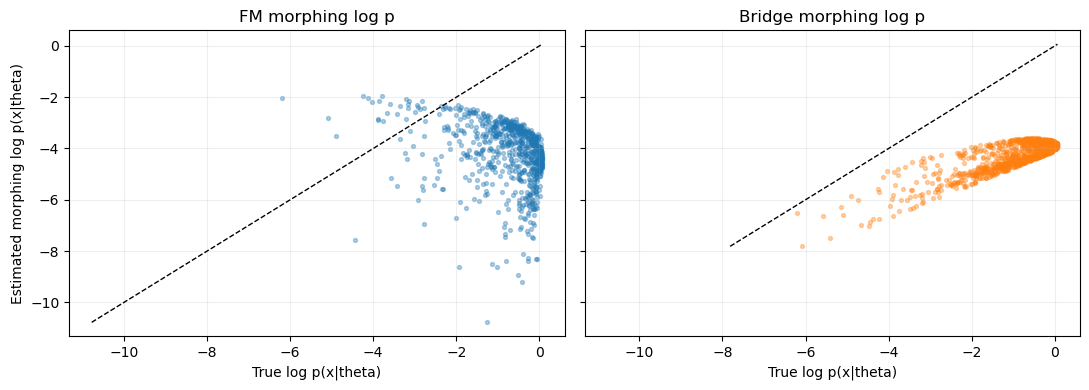

In [11]:
# Evaluate at one target theta (not necessarily a basis point)
theta_eval = (1.2, float(np.deg2rad(35.0)))
dist_eval = make_basis_dist(*theta_eval)

x_eval = dist_eval.sample((CFG["eval_samples"],))
true_log_p = dist_eval.log_prob(x_eval)

kappa_eval = torch.full((x_eval.shape[0],), theta_eval[0], device=device)
alpha_eval = torch.full((x_eval.shape[0],), theta_eval[1], device=device)
w_eval = W(kappa_eval, alpha_eval)

log_p_basis_fm = log_p_basis_from_processes(
    fm_processes,
    x_eval,
    estimator=div_estimator,
    batch_size=128,
    mc_repeats=CFG["mc_repeats"],
)
log_p_basis_bridge = log_p_basis_from_processes(
    bridge_processes,
    x_eval,
    estimator=div_estimator,
    batch_size=128,
    mc_repeats=CFG["mc_repeats"],
)

log_p_theta_fm, valid_fm = log_p_theta_from_basis(log_p_basis_fm, log_nu_basis, w_eval)
log_p_theta_bridge, valid_bridge = log_p_theta_from_basis(
    log_p_basis_bridge,
    log_nu_basis,
    w_eval,
)


def summarize(name, log_p_model, valid):
    valid_frac = valid.float().mean().item()
    if valid.any():
        nll_model = -log_p_model[valid].mean().item()
        nll_true = -true_log_p[valid].mean().item()
        mean_delta = (log_p_model[valid] - true_log_p[valid]).mean().item()
    else:
        nll_model = float("nan")
        nll_true = float("nan")
        mean_delta = float("nan")

    print(
        f"{name:>7s} | valid_frac={valid_frac:.3f} | "
        f"NLL(model)={nll_model:.3f} | NLL(true)={nll_true:.3f} | "
        f"mean(logp_model-logp_true)={mean_delta:.3f}"
    )


summarize("FM", log_p_theta_fm, valid_fm)
summarize("Bridge", log_p_theta_bridge, valid_bridge)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, log_p_model, valid, title, color in [
    (axes[0], log_p_theta_fm, valid_fm, "FM morphing log p", "tab:blue"),
    (axes[1], log_p_theta_bridge, valid_bridge, "Bridge morphing log p", "tab:orange"),
]:
    if valid.any():
        true_vals = true_log_p[valid].detach().cpu()
        model_vals = log_p_model[valid].detach().cpu()
        ax.scatter(true_vals, model_vals, s=8, alpha=0.35, color=color)
        lo = min(true_vals.min().item(), model_vals.min().item())
        hi = max(true_vals.max().item(), model_vals.max().item())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    else:
        ax.text(0.5, 0.5, "No valid points", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("True log p(x|theta)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Estimated morphing log p(x|theta)")
plt.tight_layout()
plt.show()


## 7) Diagnostics: high-accuracy eval + sanity checks

These diagnostics help separate morphing issues from per-basis density-model issues and make FM/Bridge comparisons fairer.

In [12]:
ACC_CFG = {
    "solver_steps": 20,
    "mc_repeats": 1,
    "batch_size": 256,
    "eval_samples": 256,
}

# Use Hutchinson here for robustness; ExactDivergence currently has an autograd
# graph-reuse issue in repeated log_prob integration for this workflow.
hi_estimator = nami.HutchinsonDivergence(probe="rademacher")
hi_estimator_name = "HutchinsonDivergence (high-repeat)"

print("High-accuracy config:", ACC_CFG)
print("High-accuracy estimator:", hi_estimator_name)

fm_processes_hi = make_fm_processes(
    fm_field,
    K,
    solver_steps=ACC_CFG["solver_steps"],
)
bridge_processes_hi = make_bridge_processes(
    bridge_flow,
    bridge_score,
    K,
    solver_steps=ACC_CFG["solver_steps"],
)


def _process_log_prob(process, x, *, estimator, batch_size=256, mc_repeats=1):
    mc_vals = []
    for _ in range(mc_repeats):
        vals = []
        for start in range(0, x.shape[0], batch_size):
            xb = x[start : start + batch_size]
            vals.append(process.log_prob(xb, estimator=estimator))
        mc_vals.append(torch.cat(vals, dim=0))
    return torch.stack(mc_vals, dim=0).mean(dim=0)


def _stats_vs_truth(log_p_model, true_log_p, valid):
    out = {
        "valid_frac": valid.float().mean().item(),
        "nll_model": float("nan"),
        "nll_true": float("nan"),
        "mean_delta": float("nan"),
    }
    if valid.any():
        out["nll_model"] = -log_p_model[valid].mean().item()
        out["nll_true"] = -true_log_p[valid].mean().item()
        out["mean_delta"] = (log_p_model[valid] - true_log_p[valid]).mean().item()
    return out


def evaluate_theta(theta_eval, *, processes_fm, processes_bridge, estimator, cfg, tag="eval"):
    dist_eval = make_basis_dist(*theta_eval)
    x_eval = dist_eval.sample((cfg["eval_samples"],))
    true_log_p = dist_eval.log_prob(x_eval)

    kappa_eval = torch.full((x_eval.shape[0],), float(theta_eval[0]), device=device)
    alpha_eval = torch.full((x_eval.shape[0],), float(theta_eval[1]), device=device)
    w_eval = W(kappa_eval, alpha_eval)

    log_p_basis_fm = log_p_basis_from_processes(
        processes_fm,
        x_eval,
        estimator=estimator,
        batch_size=cfg["batch_size"],
        mc_repeats=cfg["mc_repeats"],
    )
    log_p_basis_bridge = log_p_basis_from_processes(
        processes_bridge,
        x_eval,
        estimator=estimator,
        batch_size=cfg["batch_size"],
        mc_repeats=cfg["mc_repeats"],
    )

    log_p_theta_fm, valid_fm = log_p_theta_from_basis(log_p_basis_fm, log_nu_basis, w_eval)
    log_p_theta_bridge, valid_bridge = log_p_theta_from_basis(
        log_p_basis_bridge,
        log_nu_basis,
        w_eval,
    )

    st_fm = _stats_vs_truth(log_p_theta_fm, true_log_p, valid_fm)
    st_bridge = _stats_vs_truth(log_p_theta_bridge, true_log_p, valid_bridge)

    print(f"[{tag}] theta={theta_eval}")
    print(
        f"     FM | valid_frac={st_fm['valid_frac']:.3f} | "
        f"NLL(model)={st_fm['nll_model']:.3f} | NLL(true)={st_fm['nll_true']:.3f} | "
        f"mean(logp_model-logp_true)={st_fm['mean_delta']:.3f}"
    )
    print(
        f" Bridge | valid_frac={st_bridge['valid_frac']:.3f} | "
        f"NLL(model)={st_bridge['nll_model']:.3f} | NLL(true)={st_bridge['nll_true']:.3f} | "
        f"mean(logp_model-logp_true)={st_bridge['mean_delta']:.3f}"
    )

    return {
        "theta": theta_eval,
        "x_eval": x_eval,
        "true_log_p": true_log_p,
        "fm": {"log_p": log_p_theta_fm, "valid": valid_fm, "stats": st_fm},
        "bridge": {"log_p": log_p_theta_bridge, "valid": valid_bridge, "stats": st_bridge},
    }


High-accuracy config: {'solver_steps': 20, 'mc_repeats': 1, 'batch_size': 256, 'eval_samples': 256}
High-accuracy estimator: HutchinsonDivergence (high-repeat)


[high-accuracy off-basis] theta=(1.2, 0.6108652381980153)
     FM | valid_frac=0.816 | NLL(model)=4.111 | NLL(true)=0.799 | mean(logp_model-logp_true)=-3.312
 Bridge | valid_frac=1.000 | NLL(model)=4.252 | NLL(true)=0.916 | mean(logp_model-logp_true)=-3.336


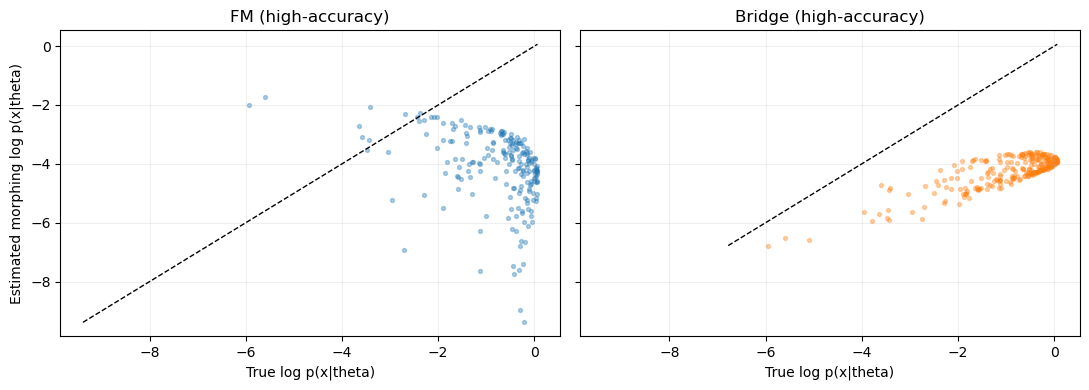

In [13]:
# Off-basis high-accuracy evaluation (same theta as before)
hi_eval = evaluate_theta(
    theta_eval=(1.2, float(np.deg2rad(35.0))),
    processes_fm=fm_processes_hi,
    processes_bridge=bridge_processes_hi,
    estimator=hi_estimator,
    cfg=ACC_CFG,
    tag="high-accuracy off-basis",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, key, title, color in [
    (axes[0], "fm", "FM (high-accuracy)", "tab:blue"),
    (axes[1], "bridge", "Bridge (high-accuracy)", "tab:orange"),
]:
    valid = hi_eval[key]["valid"]
    if valid.any():
        true_vals = hi_eval["true_log_p"][valid].detach().cpu()
        pred_vals = hi_eval[key]["log_p"][valid].detach().cpu()
        ax.scatter(true_vals, pred_vals, s=8, alpha=0.35, color=color)
        lo = min(true_vals.min().item(), pred_vals.min().item())
        hi = max(true_vals.max().item(), pred_vals.max().item())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    else:
        ax.text(0.5, 0.5, "No valid points", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("True log p(x|theta)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Estimated morphing log p(x|theta)")
plt.tight_layout()
plt.show()


In [14]:
# Basis-point sanity sweep: theta exactly at each basis point
print("Basis-point sanity sweep")
print("idx | FM valid | FM delta NLL | Bridge valid | Bridge delta NLL")
print("----+----------+--------------+--------------+-----------------")

basis_sanity = []
basis_cfg = {**ACC_CFG, "eval_samples": 1024, "mc_repeats": max(2, ACC_CFG["mc_repeats"] // 2)}

for i, theta_i in enumerate(basis_points):
    out = evaluate_theta(
        theta_eval=(float(theta_i[0]), float(theta_i[1])),
        processes_fm=fm_processes_hi,
        processes_bridge=bridge_processes_hi,
        estimator=hi_estimator,
        cfg=basis_cfg,
        tag=f"basis {i}",
    )

    fm_delta_nll = out["fm"]["stats"]["nll_model"] - out["fm"]["stats"]["nll_true"]
    bridge_delta_nll = out["bridge"]["stats"]["nll_model"] - out["bridge"]["stats"]["nll_true"]

    basis_sanity.append((
        i,
        out["fm"]["stats"]["valid_frac"],
        fm_delta_nll,
        out["bridge"]["stats"]["valid_frac"],
        bridge_delta_nll,
    ))

    print(
        f"{i:3d} | {out['fm']['stats']['valid_frac']:8.3f} | {fm_delta_nll:12.3f} | "
        f"{out['bridge']['stats']['valid_frac']:12.3f} | {bridge_delta_nll:15.3f}"
    )


Basis-point sanity sweep
idx | FM valid | FM delta NLL | Bridge valid | Bridge delta NLL
----+----------+--------------+--------------+-----------------
[basis 0] theta=(1.0, 0.0)
     FM | valid_frac=1.000 | NLL(model)=3.410 | NLL(true)=0.831 | mean(logp_model-logp_true)=-2.579
 Bridge | valid_frac=1.000 | NLL(model)=4.104 | NLL(true)=0.831 | mean(logp_model-logp_true)=-3.272
  0 |    1.000 |        2.579 |        1.000 |           3.272
[basis 1] theta=(1.0, 1.5707963267948966)
     FM | valid_frac=1.000 | NLL(model)=1.159 | NLL(true)=0.841 | mean(logp_model-logp_true)=-0.318
 Bridge | valid_frac=1.000 | NLL(model)=4.104 | NLL(true)=0.841 | mean(logp_model-logp_true)=-3.263
  1 |    1.000 |        0.318 |        1.000 |           3.263
[basis 2] theta=(1.0, 0.7853981633974483)
     FM | valid_frac=1.000 | NLL(model)=1.916 | NLL(true)=0.841 | mean(logp_model-logp_true)=-1.075
 Bridge | valid_frac=1.000 | NLL(model)=4.298 | NLL(true)=0.841 | mean(logp_model-logp_true)=-3.458
  2 |    1

In [15]:
# Per-basis holdout diagnostics: isolate density model quality for each basis i
HOLDOUT_N = 768
holdout_cfg = {"batch_size": ACC_CFG["batch_size"], "mc_repeats": ACC_CFG["mc_repeats"]}

print("Per-basis holdout diagnostics (compare log p_i to true basis dist)")
print("idx | FM RMSE | FM bias | FM corr | Bridge RMSE | Bridge bias | Bridge corr")
print("----+---------+---------+---------+-------------+-------------+------------")

per_basis_metrics = []
for i, dist_i in enumerate(basis_dists):
    xh = dist_i.sample((HOLDOUT_N,))
    true_lp = dist_i.log_prob(xh)

    fm_lp = _process_log_prob(
        fm_processes_hi[i],
        xh,
        estimator=hi_estimator,
        batch_size=holdout_cfg["batch_size"],
        mc_repeats=holdout_cfg["mc_repeats"],
    )
    bridge_lp = _process_log_prob(
        bridge_processes_hi[i],
        xh,
        estimator=hi_estimator,
        batch_size=holdout_cfg["batch_size"],
        mc_repeats=holdout_cfg["mc_repeats"],
    )

    def _metrics(pred, truth):
        err = pred - truth
        rmse = torch.sqrt(torch.mean(err**2)).item()
        bias = torch.mean(err).item()
        pred_np = pred.detach().cpu().numpy()
        truth_np = truth.detach().cpu().numpy()
        corr = float(np.corrcoef(pred_np, truth_np)[0, 1])
        return rmse, bias, corr

    fm_rmse, fm_bias, fm_corr = _metrics(fm_lp, true_lp)
    br_rmse, br_bias, br_corr = _metrics(bridge_lp, true_lp)

    per_basis_metrics.append((i, fm_rmse, fm_bias, fm_corr, br_rmse, br_bias, br_corr))
    print(
        f"{i:3d} | {fm_rmse:7.3f} | {fm_bias:7.3f} | {fm_corr:7.3f} | "
        f"{br_rmse:11.3f} | {br_bias:11.3f} | {br_corr:10.3f}"
    )


Per-basis holdout diagnostics (compare log p_i to true basis dist)
idx | FM RMSE | FM bias | FM corr | Bridge RMSE | Bridge bias | Bridge corr
----+---------+---------+---------+-------------+-------------+------------
  0 |   2.824 |  -2.624 |   0.102 |       3.319 |      -3.295 |      0.954
  1 |   1.072 |  -0.303 |   0.150 |       3.293 |      -3.254 |      0.876
  2 |   1.518 |  -1.019 |   0.011 |       3.478 |      -3.435 |      0.858
  3 |   6.635 |  -6.447 |   0.151 |       3.066 |      -3.033 |      0.910
  4 |   1.082 |   0.527 |   0.048 |       3.718 |      -3.691 |      0.940
  5 |   2.256 |  -1.976 |   0.011 |       3.343 |      -3.305 |      0.865


### How to swap in your pheno setup

- Keep `MorphingWeights`, `signed_logsumexp`, and `log_p_theta_from_basis` unchanged.
- Replace the toy `make_basis_dist`/sampling with your per-basis event samples.
- Train either:
  - one FM velocity model per basis (or one indexed model as above), or
  - bridge velocity+score models and convert to drift via `nami.DriftFromVelocityScore`.
- Build per-basis `log p_i(x)` with `FlowMatchingProcess.log_prob`, then call `log_p_theta_from_basis`.
- Use the `valid` mask from `log_p_theta_from_basis` whenever signed morphing weights are used.